In [227]:
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
from utils import risk_assessment, summary_stats_user, create_temporal_features

In [101]:
train = pd.read_csv('clean_data/cleaned_loans_train.csv').set_index('index')
test = pd.read_csv('clean_data/cleaned_loans_test.csv').set_index('Id')
valid = pd.read_csv('clean_data/cleaned_loans_valid.csv').set_index('index')

In [174]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from category_encoders import BinaryEncoder
import matplotlib.pyplot as plt
import seaborn as sns


class AnomalyDetector:
    """OneClassSVM-based anomaly detection with automatic column type detection"""
    
    def __init__(self, feature_cols=None, nu=0.1, kernel='rbf', gamma='scale', random_state=42):
        """
        Initialize the anomaly detector with automatic column type detection.
        
        Parameters:
        -----------
        feature_cols : list, optional
            List of feature column names to use. If None, will use all columns except 'target'.
            The class will automatically detect which are numerical, categorical, or boolean.
        nu : float, default=0.1
            Upper bound on fraction of training errors and lower bound of support vectors
        kernel : str, default='rbf'
            Kernel type for OneClassSVM ('rbf', 'linear', 'poly', 'sigmoid')
        gamma : str or float, default='scale'
            Kernel coefficient
        random_state : int, default=42
            Random state for reproducibility
        """
        self.feature_cols = feature_cols
        self.numerical_cols = []
        self.categorical_cols = []
        self.boolean_cols = []
        self.nu = nu
        self.kernel = kernel
        self.gamma = gamma
        self.random_state = random_state
        self.pipeline = None
        self.feature_names = None
    
    def _detect_column_types(self, X):
        """
        Automatically detect column types from the data.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Input dataframe
        
        Returns:
        --------
        None (sets self.numerical_cols, self.categorical_cols, self.boolean_cols)
        """
        # Determine which columns to use
        if self.feature_cols is None:
            # Use all columns except 'target'
            cols_to_check = [col for col in X.columns if col != 'target']
        else:
            cols_to_check = self.feature_cols
        
        numerical = []
        categorical = []
        boolean = []
        
        for col in cols_to_check:
            if col not in X.columns:
                print(f"Warning: Column '{col}' not found in data. Skipping.")
                continue
            
            # Get unique values count and dtype
            n_unique = X[col].nunique()
            dtype = X[col].dtype
            
            # Check if column contains any non-numeric values
            is_numeric_type = dtype in ['int64', 'float64', 'int32', 'float32', 'int16', 'float16']
            
            # For numeric types, check if all non-null values are actually numeric
            if is_numeric_type:
                has_numeric_data = True
            else:
                # For object/string types, check if they can be converted to numeric
                try:
                    pd.to_numeric(X[col].dropna(), errors='raise')
                    has_numeric_data = True
                except (ValueError, TypeError):
                    has_numeric_data = False
            
            # Boolean detection: exactly 2 unique values AND numeric data
            if n_unique == 2 and has_numeric_data:
                boolean.append(col)
            # Categorical detection: non-numeric data OR object/category dtype
            elif not has_numeric_data or dtype == 'object' or dtype.name == 'category':
                categorical.append(col)
            # Low cardinality numeric - treat as categorical
            elif is_numeric_type and n_unique < 20:
                categorical.append(col)
            # Numerical detection: numeric dtype with high cardinality
            elif is_numeric_type:
                numerical.append(col)
            else:
                # Default to categorical for unknown types
                print(f"Warning: Uncertain type for column '{col}'. Treating as categorical.")
                categorical.append(col)
        
        self.numerical_cols = numerical
        self.categorical_cols = categorical
        self.boolean_cols = boolean
        
        print("\n" + "="*60)
        print("AUTOMATIC COLUMN TYPE DETECTION")
        print("="*60)
        print(f"Numerical columns ({len(numerical)}): {numerical}")
        print(f"Categorical columns ({len(categorical)}): {categorical}")
        print(f"Boolean columns ({len(boolean)}): {boolean}")
        print("="*60 + "\n")
    
    def _create_pipeline(self):
        """Create preprocessing and modeling pipeline"""
        transformers = []
        
        # Numerical features: StandardScaler
        if self.numerical_cols:
            transformers.append(
                ('num', StandardScaler(), self.numerical_cols)
            )
        
        # Categorical features: BinaryEncoder + StandardScaler
        if self.categorical_cols:
            transformers.append(
                ('cat', Pipeline([
                    ('binary_encoder', BinaryEncoder(cols=self.categorical_cols)),
                    ('scaler', StandardScaler())
                ]), self.categorical_cols)
            )
        
        # Boolean features: Convert to numeric first, then StandardScaler
        if self.boolean_cols:
            transformers.append(
                ('bool', Pipeline([
                    ('to_numeric', StandardScaler())  # StandardScaler handles boolean as 0/1
                ]), self.boolean_cols)
            )
        
        # Create column transformer
        preprocessor = ColumnTransformer(
            transformers=transformers,
            remainder='drop',
            verbose_feature_names_out=False
        )
        
        # Create full pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', OneClassSVM(
                nu=self.nu,
                kernel=self.kernel,
                gamma=self.gamma,
            ))
        ])
        
        return pipeline
    
    def fit(self, X_train):
        """
        Fit the anomaly detector on training data.
        
        This method:
        1. Automatically detects column types (numerical, categorical, boolean)
        2. Learns binary encoding mappings for categorical features
        3. Learns scaling parameters (mean, std) for all features
        4. Trains OneClassSVM decision boundary
        
        All learned parameters are stored and applied consistently to validation/test data.
        
        Parameters:
        -----------
        X_train : pd.DataFrame
            Training data (normal samples only)
        
        Returns:
        --------
        self
        """
        # Detect column types automatically
        self._detect_column_types(X_train)
        
        # Validate that we have at least some features
        total_features = len(self.numerical_cols) + len(self.categorical_cols) + len(self.boolean_cols)
        if total_features == 0:
            raise ValueError("No valid feature columns detected. Please check your data.")
        
        # Select only the feature columns
        all_feature_cols = self.numerical_cols + self.categorical_cols + self.boolean_cols
        X_train_features = X_train[all_feature_cols]
        
        # Create and fit pipeline
        self.pipeline = self._create_pipeline()
        self.pipeline.fit(X_train_features)
        
        # Store feature names for reference
        try:
            self.feature_names = self.pipeline['preprocessor'].get_feature_names_out()
        except:
            self.feature_names = None
        
        print(f"✓ Model trained successfully on {len(X_train_features)} samples")
        print(f"✓ Total features used: {total_features}")
        print(f"✓ Preprocessor fitted - encoding and scaling learned from training data")
        print(f"✓ All transformations will be applied consistently to validation/test data\n")
        
        return self
    
    def predict(self, X):
        """
        Predict anomalies using the trained pipeline.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data to predict (validation or test data)
        
        Returns:
        --------
        predictions : np.ndarray
            1 for normal, -1 for anomaly
        """
        if self.pipeline is None:
            raise ValueError("Model not fitted. Call fit() before predict().")
        
        # Select only the feature columns used during training
        all_feature_cols = self.numerical_cols + self.categorical_cols + self.boolean_cols
        X_features = X[all_feature_cols]
        
        return self.pipeline.predict(X_features)
    
    def decision_function(self, X):
        """
        Get anomaly scores (distance from decision boundary).
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data to score (validation or test data)
        
        Returns:
        --------
        scores : np.ndarray
            Anomaly scores (lower = more anomalous)
        """
        if self.pipeline is None:
            raise ValueError("Model not fitted. Call fit() before decision_function().")
        
        # Select only the feature columns used during training
        all_feature_cols = self.numerical_cols + self.categorical_cols + self.boolean_cols
        X_features = X[all_feature_cols]
        
        return self.pipeline.decision_function(X_features)
    
    def validate(self, X_val, y_val, threshold=None, plot=True):
        """
        Validate the model on validation data.
        
        Parameters:
        -----------
        X_val : pd.DataFrame
            Validation features
        y_val : pd.Series or np.ndarray
            True labels (1 for anomaly, 0 for normal)
        threshold : float, optional
            Custom threshold for anomaly scores
        plot : bool, default=True
            Whether to plot validation results
        
        Returns:
        --------
        results : dict
            Dictionary containing validation metrics
        """
        # Get predictions and scores
        if threshold is None:
            y_pred = self.predict(X_val)
            y_pred_binary = (y_pred == -1).astype(int)  # Convert to 1 for anomaly, 0 for normal
        else:
            scores = self.decision_function(X_val)
            y_pred_binary = (scores < threshold).astype(int)
        
        scores = self.decision_function(X_val)
        
        # Calculate metrics
        cm = confusion_matrix(y_val, y_pred_binary)
        
        results = {
            'confusion_matrix': cm,
            'classification_report': classification_report(y_val, y_pred_binary, 
                                                          target_names=['Normal', 'Anomaly'],
                                                          output_dict=True),
            'predictions': y_pred_binary,
            'anomaly_scores': scores
        }
        
        # Calculate AUC scores if possible
        try:
            results['roc_auc'] = roc_auc_score(y_val, -scores)  # Negative because lower scores = anomaly
            precision, recall, _ = precision_recall_curve(y_val, -scores)
            results['pr_auc'] = auc(recall, precision)
        except:
            results['roc_auc'] = None
            results['pr_auc'] = None
        
        # Print results
        print("=" * 60)
        print("VALIDATION RESULTS")
        print("=" * 60)
        print(f"\nConfusion Matrix:")
        print(f"                Predicted Normal  Predicted Anomaly")
        print(f"Actual Normal        {cm[0, 0]:8d}         {cm[0, 1]:8d}")
        print(f"Actual Anomaly       {cm[1, 0]:8d}         {cm[1, 1]:8d}")
        
        print(f"\nClassification Report:")
        print(classification_report(y_val, y_pred_binary, target_names=['Normal', 'Anomaly']))
        
        if results['roc_auc'] is not None:
            print(f"ROC-AUC Score: {results['roc_auc']:.4f}")
            print(f"PR-AUC Score:  {results['pr_auc']:.4f}")
        
        # Plot results
        if plot:
            self._plot_validation_results(y_val, y_pred_binary, scores, results)
        
        return results
    
    def _plot_validation_results(self, y_true, y_pred, scores, results):
        """Plot validation results"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Confusion Matrix
        sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anomaly'],
                   yticklabels=['Normal', 'Anomaly'],
                   ax=axes[0, 0])
        axes[0, 0].set_title('Confusion Matrix')
        axes[0, 0].set_ylabel('True Label')
        axes[0, 0].set_xlabel('Predicted Label')
        
        # Anomaly Score Distribution
        normal_scores = scores[y_true == 0]
        anomaly_scores = scores[y_true == 1]
        
        axes[0, 1].hist(normal_scores, bins=50, alpha=0.6, label='Normal', color='blue')
        axes[0, 1].hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', color='red')
        axes[0, 1].axvline(0, color='black', linestyle='--', label='Default Threshold')
        axes[0, 1].set_xlabel('Anomaly Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Anomaly Score Distribution')
        axes[0, 1].legend()
        
        # Metrics Bar Chart
        report = results['classification_report']
        metrics = ['precision', 'recall', 'f1-score']
        normal_values = [report['Normal'][m] for m in metrics]
        anomaly_values = [report['Anomaly'][m] for m in metrics]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        axes[1, 0].bar(x - width/2, normal_values, width, label='Normal', color='blue', alpha=0.7)
        axes[1, 0].bar(x + width/2, anomaly_values, width, label='Anomaly', color='red', alpha=0.7)
        axes[1, 0].set_xlabel('Metrics')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_title('Performance Metrics by Class')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(metrics)
        axes[1, 0].legend()
        axes[1, 0].set_ylim([0, 1])
        
        # Score Scatter Plot
        axes[1, 1].scatter(range(len(scores[y_true == 0])), scores[y_true == 0], 
                          alpha=0.5, s=10, label='Normal', color='blue')
        axes[1, 1].scatter(range(len(scores[y_true == 0]), len(scores)), scores[y_true == 1], 
                          alpha=0.5, s=10, label='Anomaly', color='red')
        axes[1, 1].axhline(0, color='black', linestyle='--', label='Default Threshold')
        axes[1, 1].set_xlabel('Sample Index')
        axes[1, 1].set_ylabel('Anomaly Score')
        axes[1, 1].set_title('Anomaly Scores by Sample')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_feature_info(self):
        """
        Get information about the detected features.
        
        Returns:
        --------
        dict : Dictionary with feature information
        """
        return {
            'numerical_cols': self.numerical_cols,
            'categorical_cols': self.categorical_cols,
            'boolean_cols': self.boolean_cols,
            'total_features': len(self.numerical_cols) + len(self.categorical_cols) + len(self.boolean_cols),
            'feature_names': self.feature_names
        }
    
    def get_feature_importance(self, X_val, y_val, n_iterations=10):
        """
        Calculate feature importance using permutation-based method.
        
        This method measures how much each feature contributes to anomaly detection
        by randomly shuffling each feature and measuring the drop in performance.
        
        Parameters:
        -----------
        X_val : pd.DataFrame
            Validation features
        y_val : pd.Series or np.ndarray
            True labels (1 for anomaly, 0 for normal)
        n_iterations : int, default=10
            Number of permutation iterations for stability
        
        Returns:
        --------
        importance_df : pd.DataFrame
            DataFrame with columns: feature, importance, importance_std, feature_type
            Sorted by importance (descending)
        """
        if self.pipeline is None:
            raise ValueError("Model not fitted. Call fit() before get_feature_importance().")
        
        print("Calculating feature importance (this may take a moment)...")
        
        # Get baseline performance
        baseline_scores = self.decision_function(X_val)
        baseline_auc = roc_auc_score(y_val, -baseline_scores)
        
        # Prepare all features
        all_features = self.numerical_cols + self.categorical_cols + self.boolean_cols
        importances = {}
        
        for feature in all_features:
            feature_importances = []
            
            for _ in range(n_iterations):
                # Create a copy and shuffle the feature
                X_val_permuted = X_val.copy()
                X_val_permuted[feature] = np.random.permutation(X_val_permuted[feature].values)
                
                # Get performance with shuffled feature
                permuted_scores = self.decision_function(X_val_permuted)
                try:
                    permuted_auc = roc_auc_score(y_val, -permuted_scores)
                except:
                    permuted_auc = baseline_auc
                
                # Importance = drop in performance
                importance = baseline_auc - permuted_auc
                feature_importances.append(importance)
            
            importances[feature] = {
                'mean': np.mean(feature_importances),
                'std': np.std(feature_importances)
            }
        
        # Create DataFrame with results
        importance_data = []
        for feature in all_features:
            # Determine feature type
            if feature in self.numerical_cols:
                feature_type = 'numerical'
            elif feature in self.categorical_cols:
                feature_type = 'categorical'
            else:
                feature_type = 'boolean'
            
            importance_data.append({
                'feature': feature,
                'importance': importances[feature]['mean'],
                'importance_std': importances[feature]['std'],
                'feature_type': feature_type
            })
        
        importance_df = pd.DataFrame(importance_data)
        importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
        
        # Print top features
        print("\n" + "="*60)
        print("FEATURE IMPORTANCE ANALYSIS")
        print("="*60)
        print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
        print(f"\nTop 10 Most Important Features:")
        print("-" * 60)
        for idx, row in importance_df.head(10).iterrows():
            print(f"{idx+1:2d}. {row['feature']:30s} | {row['importance']:7.4f} ± {row['importance_std']:6.4f} | {row['feature_type']}")
        
        if len(importance_df) > 10:
            print(f"\n... and {len(importance_df) - 10} more features")
        
        # Identify potentially useless features
        useless_threshold = 0.001
        useless_features = importance_df[importance_df['importance'] < useless_threshold]
        if len(useless_features) > 0:
            print(f"\n⚠ {len(useless_features)} features with very low importance (<{useless_threshold}):")
            print("  ", list(useless_features['feature'].values))
        
        print("="*60 + "\n")
        
        return importance_df
    
    def plot_feature_importance(self, importance_df, top_n=20):
        """
        Plot feature importance.
        
        Parameters:
        -----------
        importance_df : pd.DataFrame
            Output from get_feature_importance()
        top_n : int, default=20
            Number of top features to display
        """
        # Select top N features
        plot_data = importance_df.head(top_n).copy()
        
        # Create color map based on feature type
        color_map = {'numerical': 'steelblue', 'categorical': 'coral', 'boolean': 'mediumseagreen'}
        colors = [color_map[ft] for ft in plot_data['feature_type']]
        
        # Create plot
        fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
        
        y_pos = np.arange(len(plot_data))
        ax.barh(y_pos, plot_data['importance'], xerr=plot_data['importance_std'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(plot_data['feature'])
        ax.invert_yaxis()
        ax.set_xlabel('Importance (Drop in ROC-AUC)')
        ax.set_title(f'Top {top_n} Feature Importance for Anomaly Detection')
        ax.grid(axis='x', alpha=0.3)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', label='Numerical'),
            Patch(facecolor='coral', label='Categorical'),
            Patch(facecolor='mediumseagreen', label='Boolean')
        ]
        ax.legend(handles=legend_elements, loc='lower right')
        
        plt.tight_layout()
        plt.show()



In [229]:
train = create_temporal_features(risk_assessment(train))
valid = create_temporal_features(risk_assessment(valid))
test = create_temporal_features(risk_assessment(test))

In [ ]:
# train.CreditScore = np.log(train.CreditScore+1)
# valid.CreditScore = np.log(valid.CreditScore+1)
# test.CreditScore = np.log(test.CreditScore+1)


In [289]:
feature_cols = [
'CreditScore_is_outlier',
'OriginalDTI_is_outlier',
'EstimatedLTV_all_MissFlag',
'DebtServiceRatio',
'LTV_DTI_Interaction',
'CreditScore_LTV_Ratio',
'CreditScore_DTI_Ratio',
'HighRiskCredit',
'HighInterestRate',
'CompositeRiskScore',
'avg_repayment_ratio',
'std_repayment_ratio',
'pct_months_late',
]


# feature_cols = [
#  'CreditScore',
#  'FirstTimeHomebuyerFlag',
#  'MI_Pct',
#  'NumberOfUnits',
#  'OccupancyStatus',
#  'OriginalCLTV',
#  'OriginalDTI',
#  'OriginalUPB',
#  'OriginalLTV',
#  'OriginalInterestRate',
#  'Channel',
#  'ProductType',
#  'PropertyState',
#  'PropertyType',
#  'LoanPurpose',
#  'OriginalLoanTerm',
#  'NumberOfBorrowers',
#  'ProgramIndicator',
#  'PropertyValMethod',
# #  '0_CurrentActualUPB',
# #  '0_CurrentInterestRate',
# #  '0_CurrentNonInterestBearingUPB',
# #  '0_EstimatedLTV',
# #  '0_InterestBearingUPB',
# #  '0_LoanAge',
# #  '0_MonthlyReportingPeriod',
# #  '0_RemainingMonthsToLegalMaturity',
# #  '1_CurrentActualUPB',
# #  '1_CurrentInterestRate',
# #  '1_CurrentNonInterestBearingUPB',
# #  '1_EstimatedLTV',
# #  '1_InterestBearingUPB',
# #  '1_LoanAge',
# #  '1_MonthlyReportingPeriod',
# #  '1_RemainingMonthsToLegalMaturity',
# #  '2_CurrentActualUPB',
# #  '2_CurrentInterestRate',
# #  '2_CurrentNonInterestBearingUPB',
# #  '2_EstimatedLTV',
# #  '2_InterestBearingUPB',
# #  '2_LoanAge',
# #  '2_MonthlyReportingPeriod',
# #  '2_RemainingMonthsToLegalMaturity',
# #  '3_CurrentActualUPB',
# #  '3_CurrentInterestRate',
# #  '3_CurrentNonInterestBearingUPB',
# #  '3_EstimatedLTV',
# #  '3_InterestBearingUPB',
# #  '3_LoanAge',
# #  '3_MonthlyReportingPeriod',
# #  '3_RemainingMonthsToLegalMaturity',
# #  '4_CurrentActualUPB',
# #  '4_CurrentInterestRate',
# #  '4_CurrentNonInterestBearingUPB',
# #  '4_EstimatedLTV',
# #  '4_InterestBearingUPB',
# #  '4_LoanAge',
# #  '4_MonthlyReportingPeriod',
# #  '4_RemainingMonthsToLegalMaturity',
# #  '5_CurrentActualUPB',
# #  '5_CurrentInterestRate',
# #  '5_CurrentNonInterestBearingUPB',
# #  '5_EstimatedLTV',
# #  '5_InterestBearingUPB',
# #  '5_LoanAge',
# #  '5_MonthlyReportingPeriod',
# #  '5_RemainingMonthsToLegalMaturity',
# #  '6_CurrentActualUPB',
# #  '6_CurrentInterestRate',
# #  '6_CurrentNonInterestBearingUPB',
# #  '6_EstimatedLTV',
# #  '6_InterestBearingUPB',
# #  '6_LoanAge',
# #  '6_MonthlyReportingPeriod',
# #  '6_RemainingMonthsToLegalMaturity',
# #  '7_CurrentActualUPB',
# #  '7_CurrentInterestRate',
# #  '7_CurrentNonInterestBearingUPB',
# #  '7_EstimatedLTV',
# #  '7_InterestBearingUPB',
# #  '7_LoanAge',
# #  '7_MonthlyReportingPeriod',
# #  '7_RemainingMonthsToLegalMaturity',
# #  '8_CurrentActualUPB',
# #  '8_CurrentInterestRate',
# #  '8_CurrentNonInterestBearingUPB',
# #  '8_EstimatedLTV',
# #  '8_InterestBearingUPB',
# #  '8_LoanAge',
# #  '8_MonthlyReportingPeriod',
# #  '8_RemainingMonthsToLegalMaturity',
# #  '9_CurrentActualUPB',
# #  '9_CurrentInterestRate',
# #  '9_CurrentNonInterestBearingUPB',
# #  '9_EstimatedLTV',
# #  '9_InterestBearingUPB',
# #  '9_LoanAge',
# #  '9_MonthlyReportingPeriod',
# #  '9_RemainingMonthsToLegalMaturity',
# #  '10_CurrentActualUPB',
# #  '10_CurrentInterestRate',
# #  '10_CurrentNonInterestBearingUPB',
# #  '10_EstimatedLTV',
# #  '10_InterestBearingUPB',
# #  '10_LoanAge',
# #  '10_MonthlyReportingPeriod',
# #  '10_RemainingMonthsToLegalMaturity',
# #  '11_CurrentActualUPB',
# #  '11_CurrentInterestRate',
# #  '11_CurrentNonInterestBearingUPB',
# #  '11_EstimatedLTV',
# #  '11_InterestBearingUPB',
# #  '11_LoanAge',
# #  '11_MonthlyReportingPeriod',
# #  '11_RemainingMonthsToLegalMaturity',
# #  '12_CurrentActualUPB',
# #  '12_CurrentInterestRate',
# #  '12_CurrentNonInterestBearingUPB',
# #  '12_EstimatedLTV',
# #  '12_InterestBearingUPB',
# #  '12_LoanAge',
# #  '12_MonthlyReportingPeriod',
# #  '12_RemainingMonthsToLegalMaturity',
# #  '13_CurrentActualUPB',
# #  '13_CurrentInterestRate',
# #  '13_CurrentNonInterestBearingUPB',
# #  '13_EstimatedLTV',
# #  '13_InterestBearingUPB',
# #  '13_LoanAge',
# #  '13_MonthlyReportingPeriod',
# #  '13_RemainingMonthsToLegalMaturity',
#  'CreditScore_is_outlier',
#  'OriginalDTI_is_outlier',
#  'EstimatedLTV_all_MissFlag',
#  'DebtServiceRatio',
#  'LTV_DTI_Interaction',
#  'CreditScore_LTV_Ratio',
#  'CreditScore_DTI_Ratio',
#  'HighRiskCredit',
#  'HighLTV',
#  'HighDTI',
#  'HighInterestRate',
#  'CompositeRiskScore',
#  'avg_repayment_ratio',
#  'std_repayment_ratio',
#  'pct_months_late',
#  'repayment_trend_slope']

In [290]:
detector.pipeline.named_steps['model'].n_support_

array([3677], dtype=int32)

In [291]:
# Option 1: Let the class automatically detect and use all columns (except 'target')
detector = AnomalyDetector(
    feature_cols=feature_cols, 
    nu=0.12,
    kernel='rbf',
    gamma='auto'
)

# Fit on training data
detector.fit(train)

# Get feature information
feature_info = detector.get_feature_info()
print(f"Total features used: {feature_info['total_features']}")


AUTOMATIC COLUMN TYPE DETECTION
Numerical columns (6): ['DebtServiceRatio', 'LTV_DTI_Interaction', 'CreditScore_LTV_Ratio', 'CreditScore_DTI_Ratio', 'avg_repayment_ratio', 'std_repayment_ratio']
Categorical columns (2): ['CompositeRiskScore', 'pct_months_late']
Boolean columns (5): ['CreditScore_is_outlier', 'OriginalDTI_is_outlier', 'EstimatedLTV_all_MissFlag', 'HighRiskCredit', 'HighInterestRate']

✓ Model trained successfully on 30504 samples
✓ Total features used: 13
✓ Preprocessor fitted - encoding and scaling learned from training data
✓ All transformations will be applied consistently to validation/test data

Total features used: 13


In [294]:
val_anomaly_score = detector.decision_function(X_val)


In [295]:
pd.DataFrame({    'index': valid.index,
    'target': val_anomaly_score})

,index,target
0,2.0,28.196817
1,11.0,33.344256
2,22.0,-3.964218
3,38.0,34.723778
4,39.0,36.986822
...,...,...
5365,49282.0,18.392070
5366,49292.0,51.392445
5367,49293.0,33.676699
5368,49295.0,21.257684



VALIDATING ON VALIDATION SET
VALIDATION RESULTS

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal            4111              582
Actual Anomaly            509              168

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.88      0.88      4693
     Anomaly       0.22      0.25      0.24       677

    accuracy                           0.80      5370
   macro avg       0.56      0.56      0.56      5370
weighted avg       0.81      0.80      0.80      5370

ROC-AUC Score: 0.6062
PR-AUC Score:  0.1776


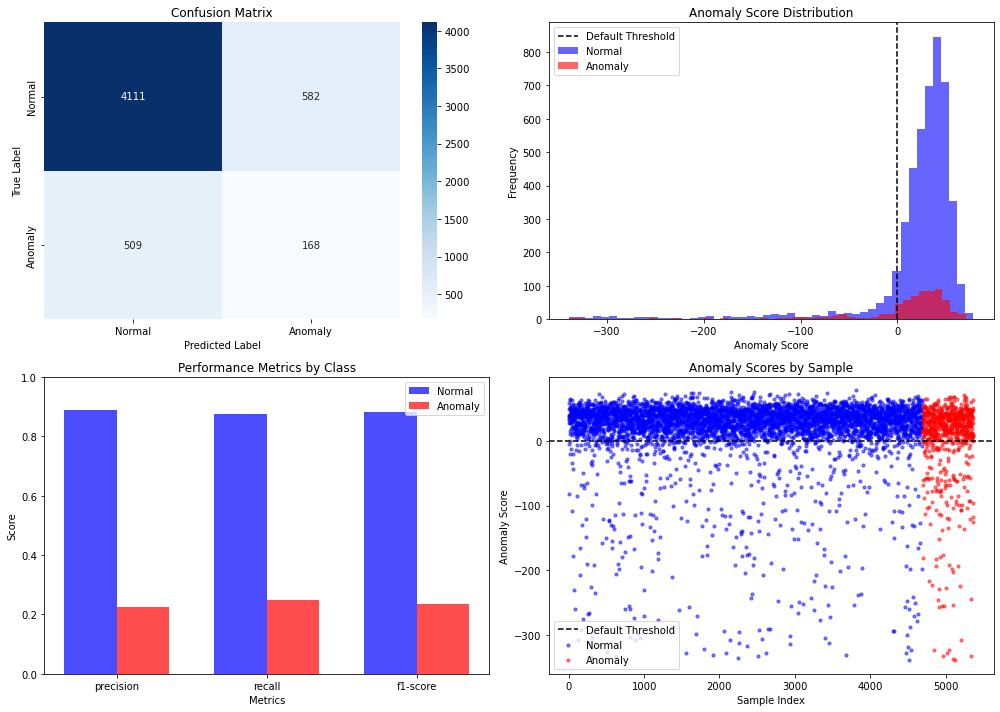

In [292]:
# Validate on validation set
print("\n" + "="*60)
print("VALIDATING ON VALIDATION SET")
print("="*60)
X_val = valid.drop(columns=['target'], errors='ignore')
y_val = valid['target']
results = detector.validate(X_val, y_val, plot=True)

In [287]:
# Predict on test set
print("\n" + "="*60)
print("PREDICTING ON TEST SET")
print("="*60)
test_predictions = detector.predict(test)
test_anomaly_scores = detector.decision_function(test)

# Count anomalies in test set
n_anomalies = (test_predictions == -1).sum()
print(f"Test set predictions:")
print(f"  Total samples: {len(test_predictions)}")
print(f"  Predicted anomalies: {n_anomalies} ({n_anomalies/len(test_predictions)*100:.2f}%)")
print(f"  Predicted normal: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(test_predictions)*100:.2f}%)")



PREDICTING ON TEST SET
Test set predictions:
  Total samples: 13426
  Predicted anomalies: 1828 (13.62%)
  Predicted normal: 11598 (86.38%)


In [266]:
# Optional: Save predictions with normalized anomaly scores
# Scale anomaly scores to [0, 1] range where 0 = normal, 1 = anomaly
# OneClassSVM scores: higher = more normal, lower = more anomalous
# So we need to invert and normalize
min_score = test_anomaly_scores.min()
max_score = test_anomaly_scores.max()

# Invert and normalize: (max - score) / (max - min)
# This maps: high scores (normal) -> 0, low scores (anomaly) -> 1
if max_score != min_score:
    normalized_anomaly_scores = (max_score - test_anomaly_scores) / (max_score - min_score)
else:
    normalized_anomaly_scores = np.zeros_like(test_anomaly_scores)

test_results = pd.DataFrame({
    'target': normalized_anomaly_scores,  # [0, 1] where 1 = anomaly
    'raw_anomaly_score': test_anomaly_scores,  # Original scores for reference
    'prediction': test_predictions,  # 1 = normal, -1 = anomaly
    'is_anomaly': (test_predictions == -1).astype(int)  # 1 = anomaly, 0 = normal
})

In [267]:
test_results[['target']].reset_index().to_csv('test_predictions.csv', index=False)

array([[<AxesSubplot:title={'center':'target'}>]], dtype=object)

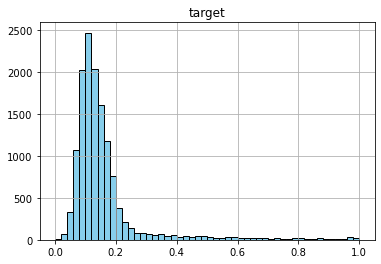

In [268]:
test_results.hist(column='target', bins=50, color='skyblue', edgecolor='black')